# Pertemuan 4 - Eksplorasi Statistik Dataset Iris

## Data Science Dasar
### Program Studi Informatika

**Nama:** Alini Syawalia Riski Fenanda  
**NIM:** 240401010213

---

## Tujuan Praktikum
Pada praktikum ini dilakukan eksplorasi statistik terhadap dataset Iris menggunakan Python dan library data science seperti Pandas, NumPy, Seaborn, dan Matplotlib.

Analisis meliputi:
1. Load dan inspeksi dataset
2. Statistik deskriptif
3. Analisis distribusi data
4. Boxplot per spesies
5. Korelasi Pearson
6. Scatter plot dan heatmap

In [2]:
# ============================================
# IMPORT LIBRARY
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Setting visualisasi
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

print("Library berhasil diimport")

Library berhasil diimport


# Langkah 1 - Load & Inspect Dataset

Dataset Iris dimuat menggunakan library Seaborn.  
Selanjutnya dilakukan pengecekan:
- Shape dataset
- Tipe data
- Data awal
- Statistik deskriptif dasar

In [3]:
# ============================================
# LOAD DATASET IRIS
# ============================================

df = sns.load_dataset('iris')

print("=== SHAPE DATASET ===")
print(df.shape)

print("\n=== TIPE DATA ===")
print(df.dtypes)

print("\n=== 5 DATA PERTAMA ===")
display(df.head())

print("\n=== STATISTIK DESKRIPTIF ===")
display(df.describe().round(3))

=== SHAPE DATASET ===
(150, 5)

=== TIPE DATA ===
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

=== 5 DATA PERTAMA ===


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



=== STATISTIK DESKRIPTIF ===


,sepal_length,sepal_width,petal_length,petal_width
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


## Interpretasi

Dataset Iris memiliki:
- 150 baris data
- 5 kolom
- 4 kolom numerik
- 1 kolom kategorikal (species)

Dataset ini berisi pengukuran bunga Iris berdasarkan:
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

Serta klasifikasi spesies:
- Setosa
- Versicolor
- Virginica

# Langkah 2 - Statistik Deskriptif Lengkap

Pada tahap ini dilakukan perhitungan:
- Mean
- Median
- Standar Deviasi
- Varians
- Skewness
- Kurtosis

Untuk setiap kolom numerik.

In [4]:
# ============================================
# STATISTIK DESKRIPTIF LENGKAP
# ============================================

numeric_cols = df.select_dtypes(include='number').columns

for col_name in numeric_cols:

    col = df[col_name]

    print(f"\n========== {col_name.upper()} ==========")

    print(f"Mean       : {col.mean():.3f}")
    print(f"Median     : {col.median():.3f}")
    print(f"Std Dev    : {col.std():.3f}")
    print(f"Varians    : {col.var():.3f}")
    print(f"Skewness   : {col.skew():.3f}")
    print(f"Kurtosis   : {col.kurt():.3f}")


========== SEPAL_LENGTH ==========
Mean       : 5.843
Median     : 5.800
Std Dev    : 0.828
Varians    : 0.686
Skewness   : 0.315
Kurtosis   : -0.552

========== SEPAL_WIDTH ==========
Mean       : 3.057
Median     : 3.000
Std Dev    : 0.436
Varians    : 0.190
Skewness   : 0.319
Kurtosis   : 0.228

========== PETAL_LENGTH ==========
Mean       : 3.758
Median     : 4.350
Std Dev    : 1.765
Varians    : 3.116
Skewness   : -0.275
Kurtosis   : -1.402

========== PETAL_WIDTH ==========
Mean       : 1.199
Median     : 1.300
Std Dev    : 0.762
Varians    : 0.581
Skewness   : -0.103
Kurtosis   : -1.341


## Interpretasi Statistik

- Mean menunjukkan rata-rata data
- Median menunjukkan nilai tengah
- Standar deviasi menunjukkan persebaran data
- Varians menunjukkan tingkat variasi data
- Skewness menunjukkan kemencengan distribusi
- Kurtosis menunjukkan tingkat keruncingan distribusi

Nilai skewness mendekati 0 menunjukkan distribusi relatif simetris.

# Langkah 3 - Analisis Distribusi

Pada tahap ini dilakukan:
- Histogram
- KDE (Kernel Density Estimation)
- Garis Mean
- Garis Median

Untuk kolom `sepal_length`.

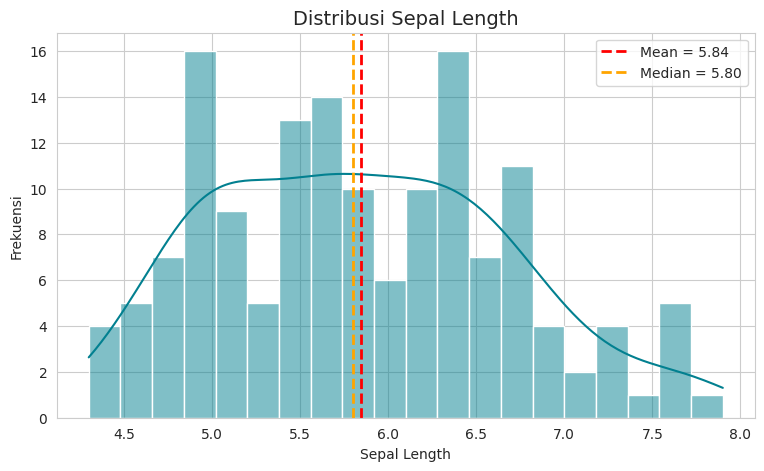

In [5]:
# ============================================
# HISTOGRAM + KDE
# ============================================

fig, ax = plt.subplots(figsize=(9,5))

sns.histplot(
    df['sepal_length'],
    kde=True,
    bins=20,
    color='#028090',
    ax=ax
)

# Garis mean
ax.axvline(
    df['sepal_length'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean = {df['sepal_length'].mean():.2f}"
)

# Garis median
ax.axvline(
    df['sepal_length'].median(),
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f"Median = {df['sepal_length'].median():.2f}"
)

ax.set_title("Distribusi Sepal Length", fontsize=14)
ax.set_xlabel("Sepal Length")
ax.set_ylabel("Frekuensi")

plt.legend()
plt.show()

## Interpretasi Distribusi

Distribusi `sepal_length` terlihat cukup mendekati distribusi normal.

Hal ini terlihat dari:
- Bentuk histogram yang relatif simetris
- Nilai mean dan median yang berdekatan
- Kurva KDE yang menyerupai lonceng (bell curve)

Namun masih terdapat sedikit kemencengan ke kanan (positive skew).

# Langkah 4 - Boxplot per Spesies

Visualisasi ini digunakan untuk:
- Membandingkan distribusi antar spesies
- Mendeteksi outlier
- Melihat persebaran data

/tmp/ipykernel_9605/2864497943.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_9605/2864497943.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


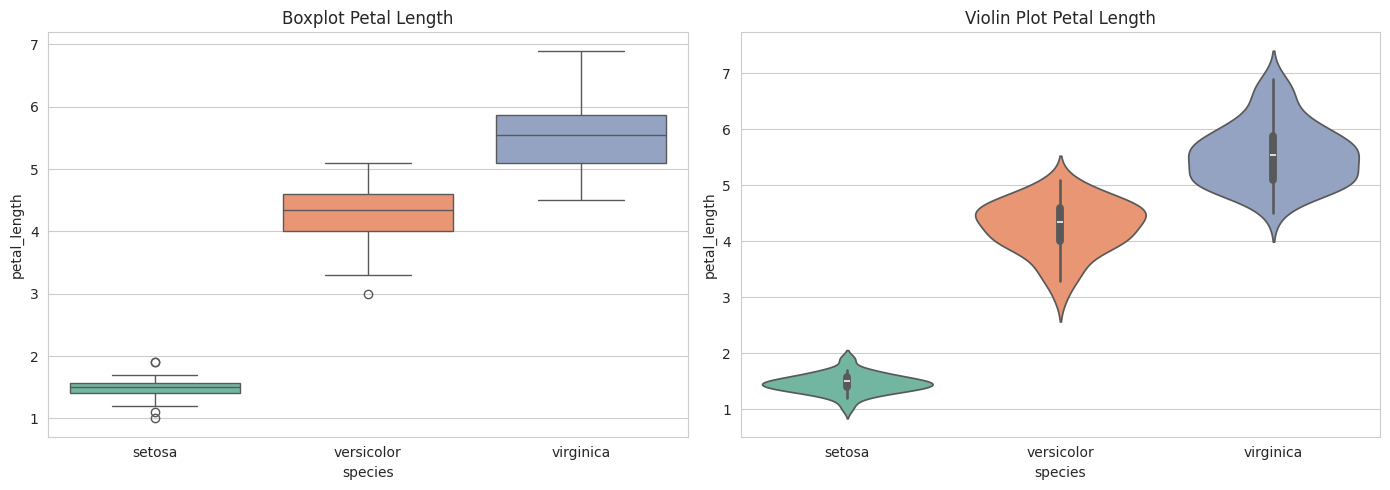

In [6]:
# ============================================
# BOXPLOT DAN VIOLIN PLOT
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Boxplot
sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title("Boxplot Petal Length")

# Violin Plot
sns.violinplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2',
    inner='box',
    ax=axes[1]
)

axes[1].set_title("Violin Plot Petal Length")

plt.tight_layout()
plt.show()

## Interpretasi Boxplot

- Spesies **Virginica** memiliki nilai `petal_length` terbesar
- Spesies **Setosa** memiliki nilai terkecil
- Spesies **Virginica** juga memiliki persebaran data paling luas

Dari visualisasi terlihat bahwa setiap spesies memiliki karakteristik ukuran mahkota bunga yang berbeda.

# Langkah 5 - Matriks Korelasi Pearson

Korelasi Pearson digunakan untuk mengukur hubungan linear antar variabel numerik.

Nilai korelasi:
- Mendekati 1  → hubungan positif kuat
- Mendekati -1 → hubungan negatif kuat
- Mendekati 0  → hubungan lemah

In [7]:
# ============================================
# KORELASI PEARSON
# ============================================

corr = df.drop('species', axis=1).corr(method='pearson')

print("=== MATRIX KORELASI ===")
display(corr.round(3))

# Mencari korelasi tertinggi
mask = np.triu(np.ones(corr.shape, dtype=bool))

corr_masked = corr.where(~mask)

max_pair = corr_masked.stack().idxmax()
min_pair = corr_masked.stack().idxmin()

print(f"\nKorelasi tertinggi : {max_pair} = {corr.loc[max_pair]:.3f}")
print(f"Korelasi terendah  : {min_pair} = {corr.loc[min_pair]:.3f}")

=== MATRIX KORELASI ===


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.118,0.872,0.818
sepal_width,-0.118,1.000,-0.428,-0.366
petal_length,0.872,-0.428,1.000,0.963
petal_width,0.818,-0.366,0.963,1.000



Korelasi tertinggi : ('petal_width', 'petal_length') = 0.963
Korelasi terendah  : ('petal_length', 'sepal_width') = -0.428


## Interpretasi Korelasi

Pasangan variabel dengan korelasi tertinggi menunjukkan hubungan linear yang sangat kuat.

Pada dataset Iris, `petal_length` dan `petal_width` memiliki hubungan positif yang sangat tinggi.

Artinya:
- Semakin panjang mahkota bunga
- Maka cenderung semakin lebar juga

# Langkah 6 - Scatter Plot & Heatmap

Visualisasi dilakukan menggunakan:
- Scatter Plot
- Garis Regresi
- Heatmap Korelasi

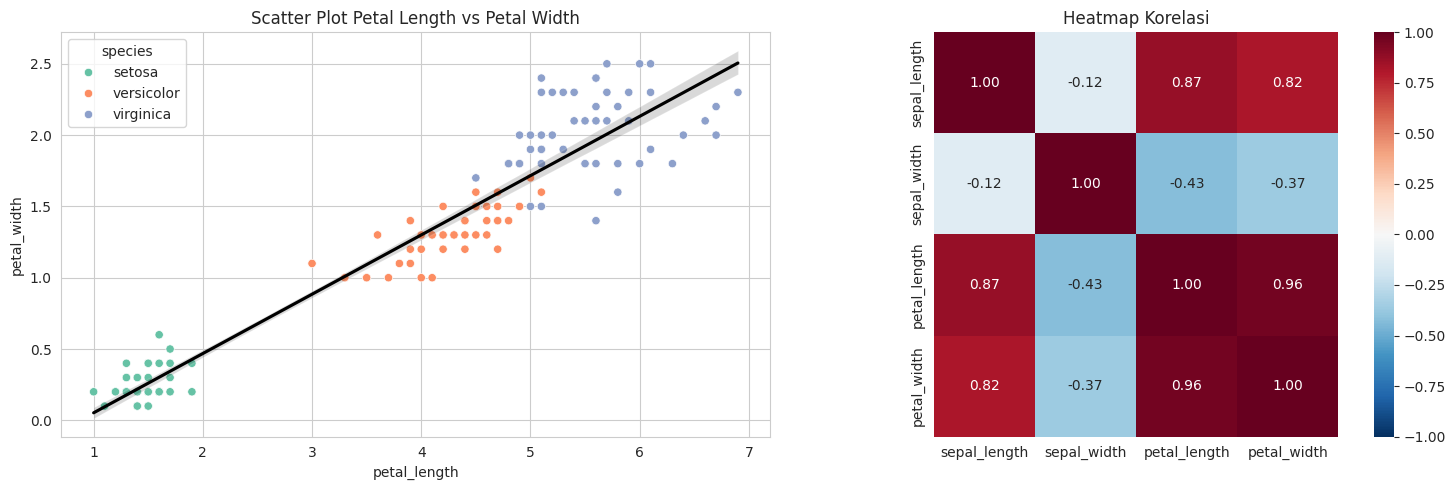

In [8]:
# ============================================
# SCATTER PLOT + HEATMAP
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(15,5))

# Scatter plot
sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    palette='Set2',
    ax=axes[0]
)

# Garis regresi
sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter=False,
    color='black',
    ax=axes[0]
)

axes[0].set_title("Scatter Plot Petal Length vs Petal Width")

# Heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1]
)

axes[1].set_title("Heatmap Korelasi")

plt.tight_layout()
plt.show()

## Interpretasi Scatter Plot & Heatmap

Scatter plot menunjukkan hubungan positif yang kuat antara:
- `petal_length`
- `petal_width`

Data antar spesies juga terlihat membentuk kelompok yang berbeda.

Heatmap memperlihatkan:
- Warna merah → korelasi positif
- Warna biru → korelasi negatif

Nilai korelasi tertinggi terdapat pada:
- `petal_length` dan `petal_width`

Sedangkan korelasi terendah terdapat pada:
- `sepal_width` dan `petal_length`

# Kesimpulan

Berdasarkan analisis statistik dataset Iris dapat disimpulkan bahwa:

1. Dataset Iris memiliki 4 fitur numerik dan 1 fitur kategorikal.
2. Distribusi `sepal_length` relatif mendekati normal.
3. Spesies Virginica memiliki ukuran petal terbesar.
4. Terdapat hubungan korelasi yang sangat kuat antara `petal_length` dan `petal_width`.
5. Visualisasi membantu memahami pola distribusi dan hubungan antar variabel dengan lebih jelas.

Praktikum ini menunjukkan bagaimana statistik deskriptif dan visualisasi data dapat digunakan untuk memahami karakteristik dataset.